In [73]:
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    RandomizedSearchCV,
    train_test_split, 
    cross_val_score, 
    cross_validate, 
    StratifiedKFold, 
    KFold
)
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import IsolationForest, RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [2]:
RANDOM_STATE = 777

In [3]:
df = pd.read_csv(
    filepath_or_buffer='car_price_dataset.csv'
)

In [4]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   str    
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   str    
 5   Transmission  2000 non-null   str    
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), str(3)
memory usage: 172.0 KB


In [6]:
df = df.rename(columns={"Mileage": "mileage_km"})

In [7]:
df.head()

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,mileage_km,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [8]:
def standardize_columns_names(df: pd.DataFrame) -> pd.DataFrame:
    df_columns = df.columns
    mapper = {column: column.lower().replace(" ", "_") for column in df_columns}
    df = df.rename(columns=mapper)
    return df

df = standardize_columns_names(df=df)

In [9]:
df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35


In [10]:
categorical_columns = df.select_dtypes(include=["str"]).columns.tolist()
numerical_columns = df.select_dtypes(include=["number"]).columns.tolist()

In [11]:
for column in categorical_columns:
    df[column] = (
        df[column]
        .str.lower()
        .str.replace(" ", "_")
    )

df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,34309.25
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,55153.60
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,41894.40
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,54046.70
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,38010.35


### Detecting Anomalities with Isolation Forest

In [12]:
isolation_forest = IsolationForest(contamination=0.1, random_state=777)
isolation_forest.fit(df[numerical_columns])

df["anomaly"] = isolation_forest.predict(df[numerical_columns])

In [13]:
df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price,anomaly
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,34309.25,-1
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,55153.60,1
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,41894.40,1
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,54046.70,-1
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,38010.35,1


In [14]:
df

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,price,anomaly
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,34309.25,-1
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,55153.60,1
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,41894.40,1
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,54046.70,-1
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,38010.35,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,hyundai,2023,4.5,diesel,manual,155033,2,3,310,61734.35,-1
1996,1997,toyota,2023,1.4,petrol,manual,25044,2,4,271,48467.80,-1
1997,1998,hyundai,2022,4.1,diesel,manual,104372,4,3,191,55714.40,1
1998,1999,bmw,2020,4.4,diesel,automatic,158047,4,1,186,53222.65,1


### Detecting Duplicates

In [15]:
df.duplicated().sum()

np.int64(0)

### Label Encoding

In [16]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoded = encoder.fit_transform(df[categorical_columns])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_columns))

df = pd.concat([df, encoded_df], axis=1)

In [17]:
df.head()

,car_id,brand,model_year,engine_size,fuel_type,transmission,mileage_km,doors,owner_count,horsepower,...,brand_honda,brand_hyundai,brand_tesla,brand_toyota,fuel_type_diesel,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,transmission_automatic,transmission_manual
0,1,ford,2023,1.2,hybrid,manual,180635,4,3,82,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,hyundai,2018,3.2,electric,manual,35628,2,4,259,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,3,bmw,2008,2.2,diesel,manual,74672,3,2,333,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,hyundai,2017,2.2,petrol,automatic,51246,4,4,381,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,5,hyundai,2012,2.4,electric,manual,147233,3,4,290,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   car_id                  2000 non-null   int64  
 1   brand                   2000 non-null   str    
 2   model_year              2000 non-null   int64  
 3   engine_size             2000 non-null   float64
 4   fuel_type               2000 non-null   str    
 5   transmission            2000 non-null   str    
 6   mileage_km              2000 non-null   int64  
 7   doors                   2000 non-null   int64  
 8   owner_count             2000 non-null   int64  
 9   horsepower              2000 non-null   int64  
 10  price                   2000 non-null   float64
 11  anomaly                 2000 non-null   int64  
 12  brand_bmw               2000 non-null   float64
 13  brand_ford              2000 non-null   float64
 14  brand_honda             2000 non-null   float64
 15

In [19]:
df = df.drop(columns=categorical_columns)
df = df.drop(columns="anomaly")

In [20]:
df.head()

,car_id,model_year,engine_size,mileage_km,doors,owner_count,horsepower,price,brand_bmw,brand_ford,brand_honda,brand_hyundai,brand_tesla,brand_toyota,fuel_type_diesel,fuel_type_electric,fuel_type_hybrid,fuel_type_petrol,transmission_automatic,transmission_manual
0,1,2023,1.2,180635,4,3,82,34309.25,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,2018,3.2,35628,2,4,259,55153.60,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,3,2008,2.2,74672,3,2,333,41894.40,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,4,2017,2.2,51246,4,4,381,54046.70,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,5,2012,2.4,147233,3,4,290,38010.35,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### Correlation

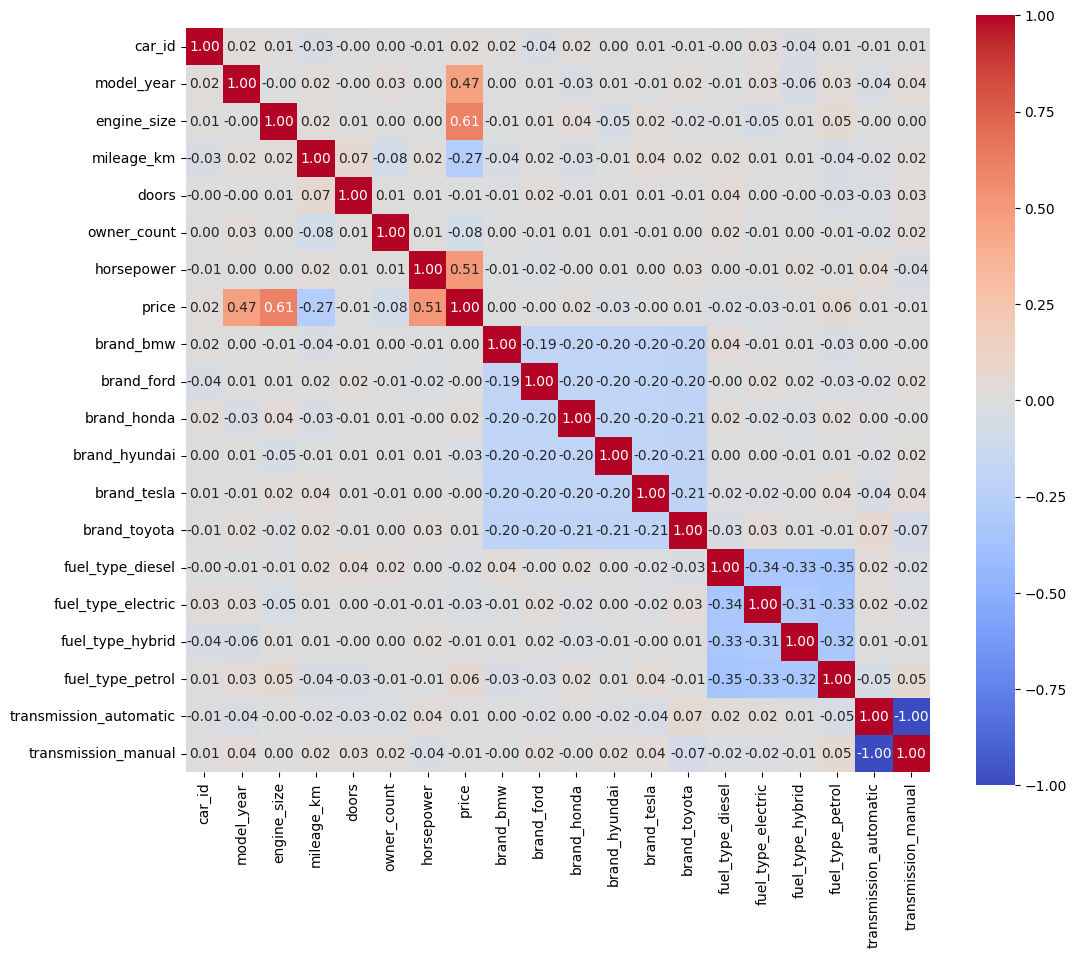

In [21]:
corr = df.corr(
    method="pearson",
    min_periods=1,
    numeric_only=False
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True
)
plt.show()

### Model Building

#### 1. Polynomial Regression

In [22]:
X = df.drop(columns="price")
y = df["price"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_poly_scaled = scaler.fit_transform(X_train_poly)
X_test_poly_scaled = scaler.transform(X_test_poly)

In [25]:
polynomial_regression = LinearRegression()
polynomial_regression.fit(X_train_poly_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred = polynomial_regression.predict(X_test_poly_scaled)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1479.2264863339217
MSE: 3033963.4926706194
rMSE: 1741.8276300112532
R2: 0.9632332219989482


##### 1.1 Polynomial Regression Pipeline

In [27]:
pipeline = Pipeline([
    ("poly_features", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("regressor", LinearRegression())
])

pipeline.fit(X_train, y_train) # no need for separate transformations, pipeline handles it internally

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly_features', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [28]:
pipeline_predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, pipeline_predictions)
mse = mean_squared_error(y_test, pipeline_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pipeline_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1479.2264863339217
MSE: 3033963.4926706194
rMSE: 1741.8276300112532
R2: 0.9632332219989482


### 2. Random Forest Regression

In [29]:
X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [30]:
rf = RandomForestRegressor(
    n_estimators=100,
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [31]:
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)
print("OOB Score:", rf.oob_score_)

MAE: 2708.4136662499977
MSE: 11655549.364893332
rMSE: 3414.0224610997116
R2: 0.8693845073997724
OOB Score: 0.8639532591058428


In [32]:
importances = rf.feature_importances_
feature_names = X.columns

importances_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

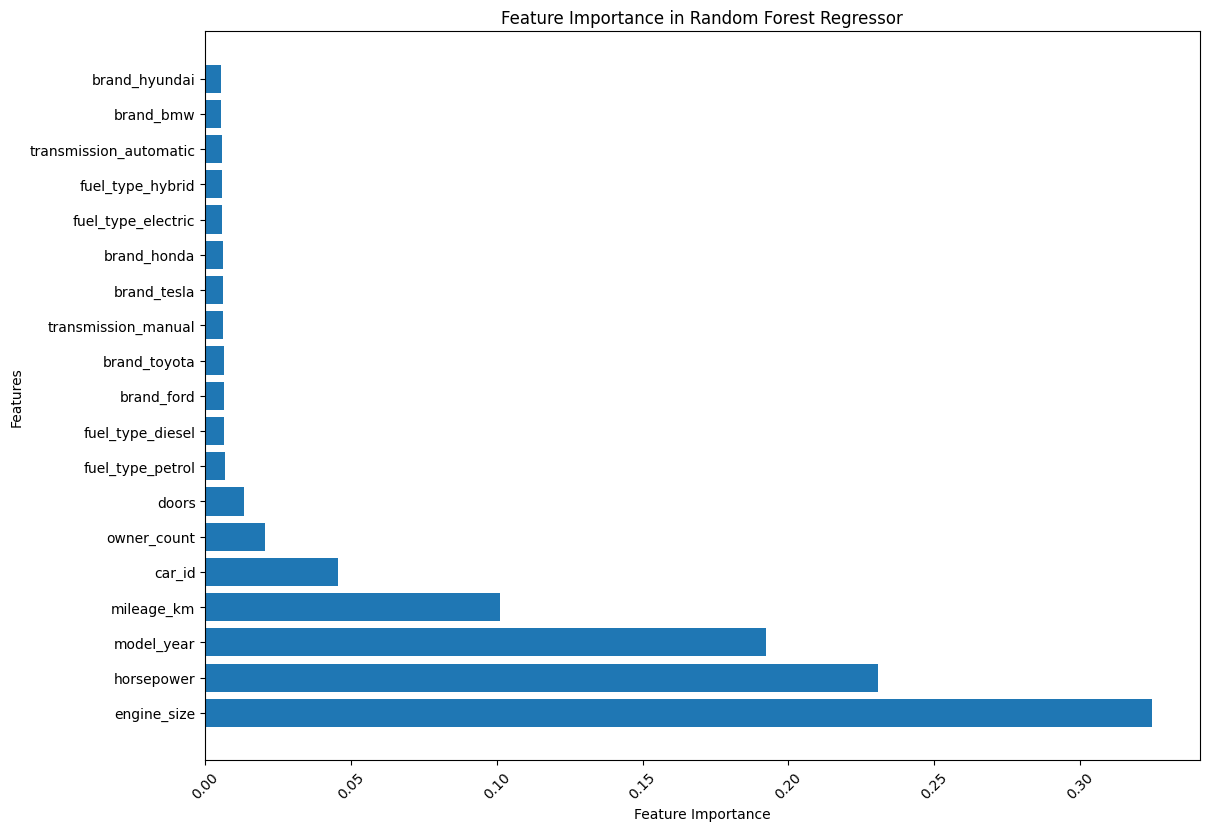

In [33]:
plt.figure(figsize=(12, 8))
plt.barh(importances_df["feature"], importances_df["importance"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest Regressor")
plt.show()


In [34]:
scoring = "r2"

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("Cross-validated R^2 scores:", scores)
print("Mean R^2:", scores.mean())

Cross-validated R^2 scores: [0.85137621 0.88071901 0.87368135 0.8651852  0.86441057]
Mean R^2: 0.8670744680470227


##### 2.1 Random Forest Regressor Pipeline

In [35]:
df_for_rfp = pd.read_csv(filepath_or_buffer='car_price_dataset.csv')

num_features = (
    df_for_rfp
    .select_dtypes(include=["number"])
    .drop(columns="Price")
    .columns.tolist()
)
cat_features = (
    df_for_rfp
    .select_dtypes(include=["object", "str", "string"])
    .columns.tolist()
)

X = df_for_rfp.drop(columns="Price")
y = df_for_rfp["Price"]

In [36]:
num_features, cat_features

(['Car_ID',
  'Model_Year',
  'Engine_Size',
  'Mileage',
  'Doors',
  'Owner_Count',
  'Horsepower'],
 ['Brand', 'Fuel_Type', 'Transmission'])

In [37]:
df_for_rfp

,Car_ID,Brand,Model_Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Horsepower,Price
0,1,Ford,2023,1.2,Hybrid,Manual,180635,4,3,82,34309.25
1,2,Hyundai,2018,3.2,Electric,Manual,35628,2,4,259,55153.60
2,3,BMW,2008,2.2,Diesel,Manual,74672,3,2,333,41894.40
3,4,Hyundai,2017,2.2,Petrol,Automatic,51246,4,4,381,54046.70
4,5,Hyundai,2012,2.4,Electric,Manual,147233,3,4,290,38010.35
...,...,...,...,...,...,...,...,...,...,...,...
1995,1996,Hyundai,2023,4.5,Diesel,Manual,155033,2,3,310,61734.35
1996,1997,Toyota,2023,1.4,Petrol,Manual,25044,2,4,271,48467.80
1997,1998,Hyundai,2022,4.1,Diesel,Manual,104372,4,3,191,55714.40
1998,1999,BMW,2020,4.4,Diesel,Automatic,158047,4,1,186,53222.65


In [38]:
df_for_rfp.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car_ID        2000 non-null   int64  
 1   Brand         2000 non-null   str    
 2   Model_Year    2000 non-null   int64  
 3   Engine_Size   2000 non-null   float64
 4   Fuel_Type     2000 non-null   str    
 5   Transmission  2000 non-null   str    
 6   Mileage       2000 non-null   int64  
 7   Doors         2000 non-null   int64  
 8   Owner_Count   2000 non-null   int64  
 9   Horsepower    2000 non-null   int64  
 10  Price         2000 non-null   float64
dtypes: float64(2), int64(6), str(3)
memory usage: 172.0 KB


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [40]:
# numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

# categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

rf = RandomForestRegressor(
    n_estimators=100,
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

# final pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", rf)
])

In [41]:
pipeline.fit(X_train, y_train)

rfp_predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, rfp_predictions)
mse = mean_squared_error(y_test, rfp_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, rfp_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)
print("OOB Score:", rf.oob_score_)

MAE: 2708.4136662499977
MSE: 11655549.364893334
rMSE: 3414.022461099712
R2: 0.8693845073997724
OOB Score: 0.8639532591058428


### 3. K-Nearest Neighbors Regression

In [42]:
X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [43]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform",      
    algorithm="auto",       
    leaf_size=30,
    p=2,                    
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 39142532.7971545
RMSE: 6256.399347640342
MAE: 5099.154500000001
R2: 0.5613573377913714


#### 3.1 KNN Regressor Pipeline

In [45]:
df_for_knn = pd.read_csv(filepath_or_buffer='car_price_dataset.csv')

num_features = (
    df_for_knn
    .select_dtypes(include=["number"])
    .drop(columns="Price")
    .columns.tolist()
)
cat_features = (
    df_for_knn
    .select_dtypes(include=["object", "str", "string"])
    .columns.tolist()
)

X = df_for_knn.drop(columns="Price")
y = df_for_knn["Price"]

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [47]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

knn = KNeighborsRegressor(
    n_neighbors=5,
    weights="uniform",      
    algorithm="auto",       
    leaf_size=30,
    p=2,                    
    n_jobs=-1
)

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", knn)
])

In [48]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [49]:
knn_pipeline_predictions = pipeline.predict(X_test)

print("MSE:", mean_squared_error(y_test, knn_pipeline_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, knn_pipeline_predictions)))
print("MAE:", mean_absolute_error(y_test, knn_pipeline_predictions))
print("R2:", r2_score(y_test, knn_pipeline_predictions))

MSE: 15422462.58532125
RMSE: 3927.1443295760405
MAE: 3207.2947249999997
R2: 0.8271713769444662


### 4. Support Vector Regression

#### 4.1 Basic Support Vector Regression

In [54]:
X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
svr = SVR(
    kernel="rbf",      
    C=1.0,
    epsilon=0.1,
    gamma="scale",     
    degree=3,          
    coef0=0.0          
)

svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [57]:
svr_predictions = svr.predict(X_test_scaled)

mae = mean_absolute_error(y_test, svr_predictions)
mse = mean_squared_error(y_test, svr_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, svr_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 7574.179866497263
MSE: 88889507.19643517
rMSE: 9428.123206473023
R2: 0.0038782037658062762


#### 4.2 Support Vector Machine Regression

In [58]:
df_for_svr = pd.read_csv(filepath_or_buffer='car_price_dataset.csv')

num_features = (
    df_for_svr
    .select_dtypes(include=["number"])
    .drop(columns="Price")
    .columns.tolist()
)
cat_features = (
    df_for_svr
    .select_dtypes(include=["object", "str", "string"])
    .columns.tolist()
)

X = df_for_svr.drop(columns="Price")
y = df_for_svr["Price"]

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [60]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", SVR())
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [ ]:
svr_pipeline_predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, svr_pipeline_predictions)
mse = mean_squared_error(y_test, svr_pipeline_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, svr_pipeline_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 7555.529378211151
MSE: 88468195.09255505
rMSE: 9405.753297453375
R2: 0.008599550333347028


### 5. Gradient Boosting Regressor

#### 5.1 Basic Gradient Boosting Regressor

In [63]:
X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE 
)

In [64]:
gradient_boosting = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    subsample=1.0,
    max_features=None,
    random_state=42
)

gradient_boosting.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [66]:
gradient_boosting_predictions = gradient_boosting.predict(X_test)

mae = mean_absolute_error(y_test, gradient_boosting_predictions)
mse = mean_squared_error(y_test, gradient_boosting_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gradient_boosting_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1747.8005612331815
MSE: 4432578.329649206
rMSE: 2105.368929581988
R2: 0.9503272317853957


#### 5.2 Gradient Boosting Regressor Pipeline

In [67]:
df_for_gradient_boosting = pd.read_csv(filepath_or_buffer='car_price_dataset.csv')

num_features = (
    df_for_gradient_boosting
    .select_dtypes(include=["number"])
    .drop(columns="Price")
    .columns.tolist()
)
cat_features = (
    df_for_gradient_boosting
    .select_dtypes(include=["object", "str", "string"])
    .columns.tolist()
)

X = df_for_gradient_boosting.drop(columns="Price")
y = df_for_gradient_boosting["Price"]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

In [69]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [71]:
gradient_boosting_predictions = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, gradient_boosting_predictions)
mse = mean_squared_error(y_test, gradient_boosting_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, gradient_boosting_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1747.8005612331815
MSE: 4432578.329649206
rMSE: 2105.368929581988
R2: 0.9503272317853957


In [ ]:
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

In [ ]:
param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__max_features": ["sqrt", "log2", None]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=RANDOM_STATE
)

search.fit(X_train, y_train)

best_model = search.best_estimator_
best_parameters = search.best_params_

In [75]:
best_model_predictions = best_model.predict(X_test)

mae = mean_absolute_error(y_test, best_model_predictions)
mse = mean_squared_error(y_test, best_model_predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, best_model_predictions)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1754.570450198443
MSE: 4339583.225088799
rMSE: 2083.1666340187
R2: 0.9513693621055805


### 6. Extreme Gradient Boosting

#### 6.1 Basic Extreme Gradient Boosting

In [79]:
X = df.drop(columns="price")
y = df["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE 
)

In [80]:
extreme_gradient_boosting = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

extreme_gradient_boosting.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [81]:
y_pred = extreme_gradient_boosting.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("rMSE:", rmse)
print("R2:", r2)

MAE: 1796.407763671875
MSE: 4659490.643629581
rMSE: 2158.5853338771626
R2: 0.9477843860781933


#### 6.2 Extreme Gradient Boosting Pipeline